In [ ]:
# -- Rainfall/tmean values CSV for website --
import pandas as pd
import rasterio
import numpy as np

rf_monthly = []
t_monthly = []
for m in range(1,13):
    with rasterio.open(f'/Users/cherryleheu/Documents/HCDP/Data/monthly/rainfall/rainfall_2025_{m:02d}.tif') as src:
        data = src.read(1).astype(float)
        nodata = src.nodata

        masked = np.ma.masked_where(data == nodata, data) / 25.4

    rfmean = masked.mean()
    rf_monthly.append(rfmean)

    with rasterio.open(f'/Users/cherryleheu/Documents/HCDP/Data/monthly/tmean/tmean_2025_{m:02d}.tif') as src:
        data = src.read(1).astype(float)
        nodata = src.nodata

        masked = np.ma.masked_where(data == nodata, data)*9/5 + 32

    tmean = masked.mean()
    t_monthly.append(tmean)

pd.DataFrame({
    'month': range(1,13),
    'rf_mean': rf_monthly,
    'tmean': t_monthly,
}).to_csv('../../public/climate-summary/monthly_summary.csv', index=False)

In [ ]:
# -- Rainfall/tmean anomaly CSV for website --
rf_mean = []
rf_anomaly = []
rf_anomaly_p = []
t_mean = []
t_anomaly = []

for m in range(1,13):
    with rasterio.open(f'/Users/cherryleheu/Documents/HCDP/Data/monthly/rainfall/rainfall_2025_{m:02d}.tif') as src:
        data = src.read(1).astype(float)
        nodata = src.nodata

        masked = np.ma.masked_where(data == nodata, data) / 25.4

    rfmean = masked.mean()
    rf_mean.append(rfmean)

    with rasterio.open(f'/Users/cherryleheu/Documents/HCDP/Data/climo/monthly/rainfall/monthly_rainfall_clim_statewide_1991-2020_{m}.tif') as src:
        data = src.read(1).astype(float)
        nodata = src.nodata

        masked = np.ma.masked_where(data == nodata, data) / 25.4
    rfanomaly = rfmean - masked.mean()
    rf_anomaly.append(rfanomaly)

    rf_anomaly_pct = (rfanomaly / masked.mean() * 100)
    rf_anomaly_p.append(rf_anomaly_pct)

    with rasterio.open(f'/Users/cherryleheu/Documents/HCDP/Data/monthly/tmean/tmean_2025_{m:02d}.tif') as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
        masked = np.ma.masked_where(data == nodata, data) * 9/5 + 32
        
    tmean = masked.mean()
    t_mean.append(tmean)

    with rasterio.open(f'/Users/cherryleheu/Documents/HCDP/Data/climo/monthly/tmean/monthly_air_temp_clim_statewide_1991-2020_{m}.tif') as src:
        data = src.read(1).astype(float)
        nodata = src.nodata

        masked = np.ma.masked_where(data == nodata, data) * 9/5 + 32
    tanomaly = tmean - masked.mean()
    t_anomaly.append(tanomaly)

    print(f'Month {m}: T mean={tmean:.2f}, T anomaly={tanomaly:.2f}')
pd.DataFrame({
    'month': range(1,13),
    'rf_anomaly_in': rf_anomaly,
    'rf_anomaly_pct':rf_anomaly_p,
    't_anomaly': t_anomaly,
}).to_csv('../../public/climate-summary/monthly_anomaly_summary.csv', index=False)

Month 1: T mean=64.62, T anomaly=1.24
Month 2: T mean=64.48, T anomaly=1.42
Month 3: T mean=64.95, T anomaly=1.41
Month 4: T mean=65.91, T anomaly=1.15
Month 5: T mean=66.53, T anomaly=0.33
Month 6: T mean=68.29, T anomaly=0.59
Month 7: T mean=69.34, T anomaly=0.51
Month 8: T mean=69.99, T anomaly=0.52
Month 9: T mean=69.47, T anomaly=0.42
Month 10: T mean=68.49, T anomaly=0.13
Month 11: T mean=66.93, T anomaly=0.37
Month 12: T mean=65.70, T anomaly=1.09


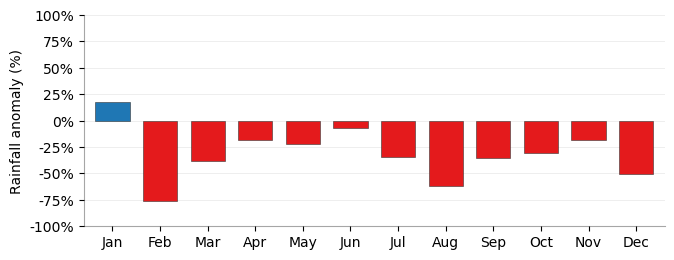

In [ ]:
# -- Rainfall anomaly chart for physical report --

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

path = "../../public/climate-summary/monthly_anomaly_summary.csv"
df = pd.read_csv(path)

df.columns = [c.lower() for c in df.columns]

month_col = "month" if "month" in df.columns else df.columns[0]
cand = ['rf_anomaly_pct']
value_col = cand[0]

df[month_col] = pd.to_numeric(df[month_col], errors="coerce")
df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
df = df.dropna(subset=[month_col, value_col]).sort_values(month_col)

df.columns = [c.lower() for c in df.columns]

month_col = "month" if "month" in df.columns else df.columns[0]
value_col = "rf_anomaly_pct"  # expected column name

df[month_col] = pd.to_numeric(df[month_col], errors="coerce")
df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
df = df.dropna(subset=[month_col, value_col]).sort_values(month_col)

month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
x = df[month_col].astype(int).to_numpy()
y = df[value_col].to_numpy()
labels = [month_names[m - 1] if 1 <= m <= 12 else str(m) for m in x]

fig, ax = plt.subplots(figsize=(6.6, 3.2))
ax.set_axisbelow(True)

ylim = 100
step = 25
ax.set_ylim(-ylim, ylim)
ticks = np.arange(-ylim, ylim + step, step)
ax.set_yticks(ticks)

ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}%"))

ax.grid(axis="y", linewidth=0.6, alpha=0.25)

pos = y >= 0
ax.bar(x[pos],  y[pos],  width=0.72, color="C0", edgecolor="0.2", linewidth=0.4)
ax.bar(x[~pos], y[~pos], width=0.72, color="#E41A1C", edgecolor="0.2", linewidth=0.4)

ax.set_xlim(0.4, 12.6)
ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel("Rainfall anomaly (%)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.35)
ax.spines["bottom"].set_alpha(0.35)

fig.subplots_adjust(left=0.10, right=0.98, top=0.88, bottom=0.22)

out_png = "../../public/climate-summary/pubs/Figure2.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight", pad_inches=0.1, transparent=True)
plt.show()

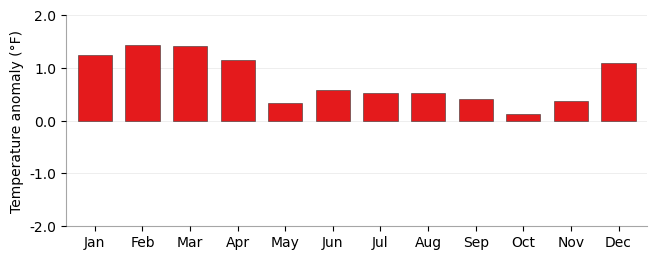

In [ ]:
# -- Tmean anomaly chart for physical report --

path = "../../public/climate-summary/monthly_anomaly_summary.csv"
df = pd.read_csv(path)

df.columns = [c.lower() for c in df.columns]

month_col = "month"
value_col = "t_anomaly"

# coerce + sort
df[month_col] = pd.to_numeric(df[month_col], errors="coerce")
df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
df = df.dropna(subset=[month_col, value_col]).sort_values(month_col)

# month labels
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
x = df[month_col].astype(int).to_numpy()
labels = [month_names[m-1] if 1 <= m <= 12 else str(m) for m in x]
y = df[value_col].to_numpy()

# figure sized for a PDF column
fig, ax = plt.subplots(figsize=(6.6, 3.2))
ax.set_axisbelow(True)


ax.grid(axis="y", linewidth=0.6, alpha=0.25)

pos = y >= 0

wet_color = "C0"       
dry_color = "#E41A1C"   

ax.bar(x[pos],  y[pos],  width=0.72, color=dry_color, edgecolor="0.2", linewidth=0.4)
ax.bar(x[~pos], y[~pos], width=0.72, color=wet_color, edgecolor="0.2", linewidth=0.4)

ax.set_xlim(0.4, 12.6)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Temperature anomaly (°F)")

y_absmax = float(max(abs(y.min()), abs(y.max()), 1.0))
step = 1
ylim = (int((y_absmax / step) + 1) * step)

ticks = np.arange(-ylim, ylim + step, step)
ticks = ticks[ticks != 0]
ax.set_yticks(ticks)

ax.set_ylim(-ylim, ylim)
ax.yaxis.set_major_locator(MultipleLocator(step))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.1f}"))

# clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.35)
ax.spines["bottom"].set_alpha(0.35)

fig.subplots_adjust(left=0.10, right=0.98, top=0.88, bottom=0.22)

# fig.savefig("monthly_rainfall_anomaly.pdf", bbox_inches="tight")
fig.savefig("../../public/climate-summary/pubs/Figure4.png", dpi=600, bbox_inches="tight",transparent=True)
plt.show()
